In [4]:
path0 = './'
filename = 'syntax_matched_sentences.txt'
threshold = 0.4  # adjust this value as needed

data = []
with open(f"{path0}{filename}", "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 5:
            sentence1, sentence2, tags1, tags2, word_overlap = parts
            try:
                if float(word_overlap) < threshold and tags1 == tags2:
                    data.append((sentence1, sentence2, tags1, word_overlap))
            except ValueError:
                continue  # skip lines with non-numeric word_overlap

print(len(data))
print(data[-1])

# removing entries with tag counts less than 5
from collections import Counter
tag_counts = Counter(tags for _, _, tags, _ in data)
data = [entry for entry in data if tag_counts[entry[2]] > 5]

print(f"Filtered size: {len(data)}")

2369
('The old tradition and a custom changed gradually', 'The soft pillow and a blanket lay comfortably', 'DT JJ NN CC DT NN VBD RB', '0.375')
Filtered size: 2098


In [5]:
# 2. Build tag→ID mapping
unique_tags = sorted({tags for _, _, tags, _ in data})
tag_to_id = {tags: idx for idx, tags in enumerate(unique_tags, start=0)}

# 3. Open five files and write out
with open(f"{path0}sentences0.txt", "w") as f1, \
     open(f"{path0}sentences1.txt", "w") as f2, \
     open(f"{path0}tags.txt",        "w") as f3, \
     open(f"{path0}group_ids.txt",   "w") as f4, \
     open(f"{path0}overlaps.txt",    "w") as f5:

    for s1, s2, tags, word_overlap in data:
        gid = tag_to_id[tags]
        f1.write(s1 + "\n")
        f2.write(s2 + "\n")
        f3.write(tags + "\n")
        f4.write(str(gid) + "\n")
        f5.write(word_overlap + "\n")

Array([ 6,  6, 14, 24, 48, 44, 36, 11, 40, 17, 37, 27, 11, 20,  6, 18, 18,
        9, 12, 40, 36,  4, 24, 36, 12,  8, 20, 12, 12, 42,  8, 32, 11, 28,
       10, 19,  6,  7, 37,  9, 14, 20,  8, 10,  9, 12, 29, 26, 21, 12,  9,
        6, 36,  4,  5, 26, 35, 38, 76, 15,  6,  7, 19, 43,  6, 17, 36, 10,
       33, 13, 35,  6,  6,  7,  9, 22, 44, 26, 11, 33,  5, 37,  7, 45, 28,
        6, 70, 30, 34, 42, 33, 12,  6, 19,  9], dtype=int32)

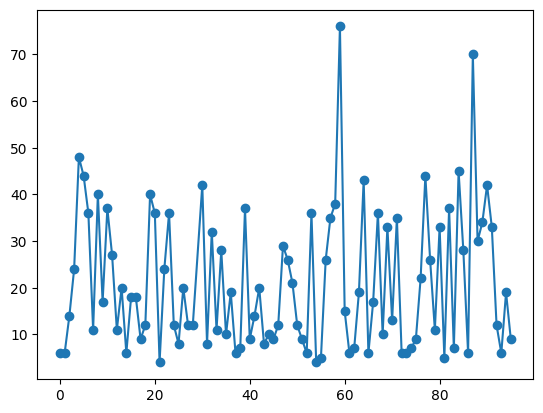

In [14]:
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

all_groups_ids = jnp.array(np.loadtxt('group_ids.txt')).astype(int)[:2000]
unique_groups_indices,counts = jnp.unique(all_groups_ids,return_counts=True)
plt.plot(unique_groups_indices, counts, marker='o')
counts

In [16]:
[1,2,3,4,5][:15]

[1, 2, 3, 4, 5]